## Medidas de centralidad y prestigio proyecto

In [20]:
# Librerias que vamos a usar
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [21]:
# Nodos y arcos de la red
nodos = pd.read_excel('nodos.xlsx')
arcos = pd.read_excel('arcos.xlsx')
nodos


,Id,Label,Headquarters Location,Operating Status,Company Type,Industry Groups,Number of Investments,Total Funding Amount Currency (in USD)
0,Tencent,Tencent,"Shenzhen, Guangdong, China",Active,For Profit,"Advertising, Gaming, Internet Services, Sales ...",693.0,1.257677e+10
1,Warburg Pincus,Warburg Pincus,"New York, New York, United States",Active,NaN,"Financial Services, Lending and Investments",433.0,3.802820e+07
2,Twitter,Twitter,"San Francisco, California, United States",Active,For Profit,"Content and Publishing, Information Technology...",10.0,4.430192e+09
3,Ubisoft,Ubisoft,"Montreuil-sous-bois, Ile-de-France, France",Active,For Profit,"Content and Publishing, Gaming, Media and Ente...",9.0,7.706506e+08
4,WeWork,WeWork,"New York, New York, United States",Active,For Profit,Real Estate,9.0,2.159578e+10
...,...,...,...,...,...,...,...,...
2206,Activation Capital,Activation Capital,NaN,Active,NaN,NaN,1.0,NaN
2207,Gavi,Gavi,"Moritzburg, Sachsen, Germany",Active,For Profit,"Commerce and Shopping, Consumer Goods, Food an...",NaN,NaN
2208,BF Holdings,BF Holdings,"Dudley, Dudley, United Kingdom",Closed,For Profit,Manufacturing,1.0,NaN
2209,GO Virginia,GO Virginia,NaN,Active,NaN,NaN,2.0,NaN


In [18]:
arcos

,Source,Target
0,IDG Capital,Tencent
1,Prosus & Naspers,Tencent
2,Lippo Group,Tencent
3,PCCW,Tencent
4,Andreessen Horowitz,Twitter
...,...,...
4176,Omnes Capital,ESL Gaming
4177,TA Associates,Bigpoint
4178,Summit Partners,Bigpoint
4179,GMT Capital,Bigpoint


In [73]:
#limpieza
nodos_clean = nodos.copy()

# 1) Eliminar columnas redundantes
nodos_clean = nodos_clean.drop(columns=['Label', 'Operating Status'], errors='ignore')

# 2) Headquarters Location → Country
nodos_clean['Country'] = (
    nodos_clean['Headquarters Location']
    .fillna('Unknown')
    .apply(lambda x: x.split(',')[-1].strip())
)
nodos_clean = nodos_clean.drop(columns=['Headquarters Location'], errors='ignore')

# 3) Company Type (NaN → Unknown)
nodos_clean['Company Type'] = nodos_clean['Company Type'].fillna('Unknown')

# 4) Industry Groups → sector principal
nodos_clean['Industry Group Main'] = (
    nodos_clean['Industry Groups']
    .fillna('Other')
    .apply(lambda x: x.split(',')[0].strip())
)
nodos_clean = nodos_clean.drop(columns=['Industry Groups'], errors='ignore')

# 5) Number of Investments (NaN → 0)
nodos_clean['Number of Investments'] = nodos_clean['Number of Investments'].fillna(0)

# 6) Marcar si hay información de funding
nodos_clean['Has Funding Info'] = nodos_clean['Total Funding Amount Currency (in USD)'].notna()

# 7) Funding por inversión (evitar división por cero)
nodos_clean['Funding per Investment'] = (
    nodos_clean['Total Funding Amount Currency (in USD)'] /
    nodos_clean['Number of Investments'].replace(0, np.nan)
)

# 8) Log del funding (opcional)
nodos_clean['Log Total Funding'] = np.log1p(
    nodos_clean['Total Funding Amount Currency (in USD)']
)

# Vista previa del resultado
nodos_clean

,Id,Company Type,Number of Investments,Total Funding Amount Currency (in USD),Country,Industry Group Main,Has Funding Info,Funding per Investment,Log Total Funding
0,Tencent,For Profit,693.0,1.257677e+10,China,Advertising,True,1.814830e+07,23.255117
1,Warburg Pincus,Unknown,433.0,3.802820e+07,United States,Financial Services,True,8.782495e+04,17.453839
2,Twitter,For Profit,10.0,4.430192e+09,United States,Content and Publishing,True,4.430192e+08,22.211709
3,Ubisoft,For Profit,9.0,7.706506e+08,France,Content and Publishing,True,8.562785e+07,20.462746
4,WeWork,For Profit,9.0,2.159578e+10,United States,Real Estate,True,2.399532e+09,23.795764
...,...,...,...,...,...,...,...,...,...
2206,Activation Capital,Unknown,1.0,NaN,Unknown,Other,False,NaN,NaN
2207,Gavi,For Profit,0.0,NaN,Germany,Commerce and Shopping,False,NaN,NaN
2208,BF Holdings,For Profit,1.0,NaN,United Kingdom,Manufacturing,False,NaN,NaN
2209,GO Virginia,Unknown,2.0,NaN,Unknown,Other,False,NaN,NaN


In [78]:
# Construir red
G = nx.DiGraph()

# Arcos primero
G.add_edges_from(
    arcos[['Source', 'Target']].itertuples(index=False, name=None)
)

# Atributos de nodos
atributos = nodos_clean.set_index('Id').to_dict('index')
nx.set_node_attributes(G, atributos)


In [79]:
#Numero de nodos
print(G.number_of_nodes())
#Numero de arcos
print(G.number_of_edges())

2106
4181


In [80]:
import networkx as nx

# Calcular grado total (entrada + salida)
grado = (
    arcos['Source'].value_counts()
    .add(arcos['Target'].value_counts(), fill_value=0)
)

# Id del nodo más conectado
id_max = grado.idxmax()

print("Nodo más conectado:")
print("Id:", id_max)


Nodo más conectado:
Id: Tiger Global Management


In [81]:
#Centralidad Eigenvector
Eige_centralidad = nx.eigenvector_centrality(G)
#Nodo con mayor centralidad
id_max = max(Eige_centralidad, key=Eige_centralidad.get)

print("Nodo con mayor Eigenvector Centrality:")
print("Id:", id_max)
print("Valor:", Eige_centralidad[id_max])

Nodo con mayor Eigenvector Centrality:
Id: Nothing
Valor: 0.3078525849762008


In [82]:
#Betweenness Top 10
import pandas as pd

bet_df = pd.DataFrame(
    bet.items(),
    columns=['Id', 'Betweenness']
)

bet_df.sort_values(
    by='Betweenness',
    ascending=False
).head(10)


,Id,Betweenness
2537,Animoca Brands,0.000020
2212,Tencent,0.000020
2222,Ubisoft,0.000012
2242,Techstars,0.000010
2259,Digital Currency Group,0.000009
2269,Google,0.000008
2870,Mirae Asset Global Investments,0.000008
3818,Didi,0.000007
2717,Bolt,0.000006
2399,Silver Lake,0.000006


In [83]:
centralidades = pd.DataFrame({
    'Id': G.nodes(),
    'Eigenvector': nx.eigenvector_centrality(G, max_iter=1000).values(),
    'Betweenness': nx.betweenness_centrality(G).values()
})

centralidades.sort_values(
    by='Betweenness',
    ascending=False
).head(10)


,Id,Eigenvector,Betweenness
326,Animoca Brands,4.198096e-02,0.000085
1,Tencent,5.890532e-09,0.000083
11,Ubisoft,1.635274e-07,0.000048
31,Techstars,2.357777e-07,0.000040
48,Digital Currency Group,5.890532e-09,0.000037
58,Google,2.343181e-07,0.000035
659,Mirae Asset Global Investments,4.197949e-02,0.000032
1607,Didi,4.736926e-07,0.000031
506,Bolt,3.793920e-06,0.000025
188,Silver Lake,2.971330e-09,0.000025


La centralidad de intermediación presenta una distribución altamente sesgada, donde la mayoría de los nodos exhiben valores cercanos a cero, mientras que un reducido subconjunto actúa como puente entre comunidades de la red.

Tal como se observa en la Tabla, únicamente un conjunto reducido de inversionistas presenta valores significativos de centralidad de intermediación, confirmando la existencia de nodos puente que conectan distintas comunidades dentro de la red.

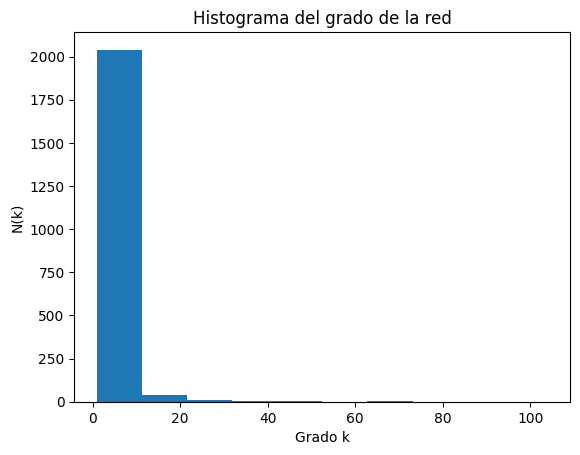

In [84]:
#Grado
grado=[]
for node in G.nodes():
    grado.append(G.degree(node))

a=plt.hist(grado)
plt.title('Histograma del grado de la red')
plt.xlabel ("Grado k")
plt.ylabel ("N(k)")
plt.show()

In [85]:
#Densidad
densidad=(2*nx.number_of_edges(G))/(nx.number_of_nodes(G)*(nx.number_of_nodes(G)-1))
densidad=round(densidad,4)
densidad

0.0019

In [86]:
#asortatividad
asortatividad =nx.degree_assortativity_coefficient(G)
asortatividad =round(asortatividad ,4)
asortatividad

0.1125

La red presenta una asortatividad positiva moderada (r = 0.1125), lo que sugiere una ligera tendencia de los inversionistas a relacionarse con actores de conectividad similar, sin evidenciar una estructura fuertemente segregada.

In [87]:
#Grado promedio
gradoProm = sum(dict(G.degree()).values()) / G.number_of_nodes()
gradoProm=round(gradoProm,4)
print(gradoProm)

3.9706


La red presenta una densidad extremadamente baja (0.0004), lo que evidencia una estructura altamente dispersa, donde las relaciones de coinversión son selectivas y se concentran en subconjuntos específicos de actores.

In [88]:
# los 20 nodos con mayor grado
from operator import itemgetter
grados = dict(G.degree())

# Ordenar
grados_ordenados = sorted(grados.items(), key=itemgetter(1), reverse=True)

# Obtener los 20 nodos
topDegree = [nodo for nodo, grado in grados_ordenados[:20]]

topDegree

['Tiger Global Management',
 'Andreessen Horowitz',
 'Y Combinator',
 'Sequoia Capital',
 'Insight Partners',
 'Accel',
 'Tencent',
 'SoftBank Vision Fund',
 'Goldman Sachs',
 'GV',
 '500 Startups',
 'Temasek Holdings',
 'SoftBank',
 'Lightspeed Venture Partners',
 'Coatue',
 'Sequoia Capital India',
 'Bessemer Venture Partners',
 'Gaingels',
 'Techstars',
 'Spark Capital']

Los nodos con mayor centralidad de grado corresponden a fondos de capital de riesgo globales y aceleradoras, caracterizados por una alta participación en coinversiones y una fuerte conectividad dentro del ecosistema

In [89]:
# 20 nodos con mayor PageRank
pr = nx.pagerank(G)

topPage = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:20]
topPage

[('LayerZero Labs', 0.003030848743698145),
 ('SWVL Technologies', 0.0024623161942131234),
 ('Functionland', 0.0021958872666544412),
 ('Polygon', 0.0021350166166807633),
 ('Sales Impact Academy', 0.0021233803023790352),
 ('Fyllo', 0.0019656580157279588),
 ('Li Auto', 0.001891306743761648),
 ('2TM', 0.001864643361059296),
 ('Uber', 0.001858489979840167),
 ('Dfns', 0.0018561853344436995),
 ('Roku', 0.001854599333171485),
 ('Trace', 0.0018522484422403146),
 ('Solarisbank', 0.0017513060507155904),
 ('Boba Network', 0.00167895818374767),
 ('Stockal', 0.0016712169592888503),
 ('Yield Guild Games Southeast Asia', 0.001642096413619241),
 ('Blockdaemon', 0.0016329074675225117),
 ('Partake Foods', 0.0016140652926094545),
 ('DigiLens', 0.0015719570195089824),
 ('Figment', 0.0015575564678356043)]

El PageRank identifica principalmente compañías receptoras de inversión que concentran capital proveniente de actores altamente centrales, destacando nodos con elevada atracción dentro del ecosistema.